Este va ser un archivo que documento la confiabilidad de los instrumentos: rendimientos y volatilidad

In [139]:
#### Importando modulos
import pandas as pd
import numpy as np
import scipy
from scipy import stats
import matplotlib.pyplot as plt


In [109]:
##### Funcion para integrar posiciones
def posiciones(df_r: pd.DataFrame, empresas: list[str], tipo:str):
    df_posiciones = pd.DataFrame()
    #### Extracciones individuales
    if tipo=='sliding':
        for i in range(22):
            tmp = scipy.io.loadmat(f'SlidingFinalPreds/pred_sliding_{i}.mat')
            df_tmp = pd.DataFrame(tmp['Ypred_final'])
            df_posiciones = pd.concat([df_posiciones, df_tmp], axis=0, ignore_index=True)
        del tmp
        df_posiciones.columns = [f'Posicion.{nom}' for nom in empresas]
    elif tipo=='expanding':
        for i in range(22):
            tmp = scipy.io.loadmat(f'ExpandingFinalPreds/pred_expanding_{i}.mat')
            df_tmp = pd.DataFrame(tmp['Ypred_final'])
            df_posiciones = pd.concat([df_posiciones, df_tmp], axis=0, ignore_index=True)
        del tmp
        df_posiciones.columns = [f'Posicion.{nom}' for nom in empresas]
    elif tipo=='todo':
        for nom in empresas:
            df_posiciones[f'Posicion.{nom}'] = [1] * df_r.shape[0]
    elif tipo=='rand':
        import random
        random.seed(42)
        for nom in empresas:
            df_posiciones[f'Posicion.{nom}'] = [random.randint(0,1) for _ in range(df_r.shape[0])]


    #### Asegurando que df_posiciones tenga mismo numero de datos
    df_posiciones = df_posiciones.iloc[:df_r.shape[0]]

    #### Camiando indices
    df_posiciones.index = df_r.index
    
    #### Sumando cantidad de posiciones
    suma = df_posiciones.sum(axis=1)

    #### Asignando posiciones equitativamente
    df_posiciones_finales = df_posiciones.div(suma, axis=0)

    #### Integrando posiciones con rendimientos
    df_integrado = pd.concat([df_r,df_posiciones_finales], axis=1, ignore_index=False)

    return df_integrado


In [110]:
##### Calculando formula para la rentabilidad del portafolio

def calc_rentabilidad(df:pd.Dataframe, empresas: list[str], tgt: int = 0.1, costo : int = 0.00001) -> pd.Dataframe:
    """
    Formula para calcular la rentabilidad de un portafolio 

    Params:
    df: el dataframe que contiene los rendimientos, EWMSD, y posiciones del portafolio
    tgt: la voltatilidad deseada para escalar la volatilidad proporcionalmente
    costo: costo de cambiar las posiciones de las acciones en un portafolio

    Return:
    df_rentabilidad: el df que contiene la rentabilidad del portafolio por las fechas marcadas
    """
    #### Calculando rentabilidad equitativa por cada accion/empresa
    df_rentabilidad = pd.DataFrame()
    for name in empresas:
        df_rentabilidad[f'Rentabilidad.{name}'] = df[name] * (tgt/df[f'EWMSD.{name}'].shift(1))  * df[f'Posicion.{name}'].shift(1) - \
        costo*abs(((tgt/df[f'EWMSD.{name}'].shift(1))*df[f'Posicion.{name}'].shift(1)) - ((tgt/df[f'EWMSD.{name}'].shift(2))*df[f'Posicion.{name}'].shift(2)))
        # df_rentabilidad[f'Rentabilidad.{name}'] = df[name] * df[f'Posicion.{name}']


    #### Elimando primera dos fila por el "shift(2)"
    df_rentabilidad_diaria = df_rentabilidad.iloc[2:]

    return df_rentabilidad_diaria



In [129]:
#### Formula para cargar y limpiar datos
def cargar(nom:str):
    ### Cargando datos
    df = pd.read_csv(nom, index_col='Date')

    ### Nombre de las 32 empresas
    empresas = df.columns.to_list()

    ### Calculando EWMSD
    for name in empresas:
        df[f'EWMSD.{name}'] = df[name].ewm(span=30, adjust=False).std()

    ### Eliminando datos
    df = df.iloc[:-62]
    df = df.iloc[345:]

    #### Calculando posiciones
    df_todo= posiciones(df, empresas, 'todo')    

    #### Calculado rentabilidades diarias de todas acciones
    todo_rentabilidad_diaria = calc_rentabilidad(df_todo, empresas)

    return todo_rentabilidad_diaria
    

In [ ]:
#### Funcion para hacer test 1 y test 2 (retest)
def test(df:pd.DataFrame, fecha_comienzo: str):
    ### Extrayendo df
    df_deseado = df.loc[fecha_comienzo:]

    ### Selecionado fechas iniciales
    df_inicial = df_deseado.iloc[:7]    #Primera semana
    df_final = df_deseado.iloc[7:14]    #Segunda semana

    ### Rendimientos
    ## Valores esperados
    df_inicial_rend_esperados = df_inicial.mean(axis=0)
    df_final_rend_esperados = df_final.mean(axis=0)

    ## Indice rendimiento
    df_indice_rend = (df_final_rend_esperados - df_inicial_rend_esperados)/df_inicial_rend_esperados


    ### Desviacion estandard 
    ## Valores
    df_inicial_std = df_inicial.std(axis=0, ddof=0)
    df_final_std = df_final.std(axis=0, ddof=0)

    ## Indice
    df_indice_std = (df_final_std - df_inicial_std)/df_inicial_std

    return df_indice_rend.to_list(), df_indice_std.to_list()

In [220]:
#### Funcion para ejecutar las pruebas
def pruebas(df: pd.DataFrame, test1_fecha: str, test2_fecha:str):
    ### Creando indices
    indice_rend_test1, indice_std_test1 = test(df, test1_fecha)
    indice_rend_test2, indice_std_test2 = test(df, test2_fecha)

    ### Probando normalidad
    norm_rend_test1_estad, norm_rend_test1_pvalor = stats.shapiro(indice_rend_test1)
    norm_rend_test2_estad, norm_rend_test2_pvalor = stats.shapiro(indice_rend_test2)
    norm_std_test1_estad, norm_std_test1_pvalor = stats.shapiro(indice_std_test1)
    norm_std_test2_estad, norm_std_test2_pvalor = stats.shapiro(indice_std_test2)

    ### Correlacion Spearman
    ALT = 'two-sided'      #'two-sided', 'less', 'greater'; solo cambia pvalor
    spear_rend_estad, spear_rend_pvalor = stats.spearmanr(indice_rend_test1, indice_rend_test2, alternative=ALT)
    spear_std_estad, spear_std_pvalor = stats.spearmanr(indice_std_test1, indice_std_test2, alternative=ALT)

    ### Correlacion Pearson
    pear_rend_estad, pear_rend_pvalor = stats.pearsonr(indice_rend_test1, indice_rend_test2)
    pear_std_estad, pear_std_pvalor = stats.pearsonr(indice_std_test1, indice_std_test2)

    ### Tabla visual
    ## Creado tabla
    data = np.array([
        [norm_rend_test1_estad, norm_rend_test1_pvalor],
        [norm_rend_test2_estad, norm_rend_test2_pvalor],
        [norm_std_test1_estad, norm_std_test1_pvalor],
        [norm_std_test2_estad, norm_std_test2_pvalor],
        [spear_rend_estad, spear_rend_pvalor],
        [spear_std_estad, spear_std_pvalor],
        [pear_rend_estad, pear_rend_pvalor],
        [pear_std_estad, pear_std_pvalor]
    ])

    ## Nombres de columnas y filas
    cols = ['Resultado', 'P-valor (>0.05?)']
    rows = ['Norm Rend Test 1','Norm Rend Test 2', 'Norm Vol Test 1','Norm Vol Test 2',
            'Spearman Rend', 'Spearman Vol', 'Pearson Rend', 'Pearson Vol']
    
    ## Creando colores
    NORM_THRESH = 0.05
    colores = [['white','white']] * 8
    print(colores[6][0])
    if (norm_rend_test1_pvalor > NORM_THRESH) and (norm_rend_test2_pvalor > NORM_THRESH):
        # Indice rendimiento son normales
        colores[6] = ['yellow', 'white']
    else: 
        colores[4] = ['yellow', 'white']

    
    if (norm_std_test1_pvalor > NORM_THRESH) and (norm_std_test2_pvalor > NORM_THRESH):
        # Inice vol son normales
        colores[7] = ['yellow', 'white']
    else: 
        colores[5] = ['yellow', 'white']

    ## Configurando tabla
    ANCHURA = 7
    ALTURA = 3
    fig, ax = plt.subplots(figsize=(ANCHURA,ALTURA))
    ax.axis('off')

    ## Creando tabla
    tabla = ax.table(
        cellText=data,           # Datos en formato lista o array
        colLabels=cols, # Encabezados de columnas
        rowLabels=rows,    # Encabezados de filas
        cellColours=colores,    # Colores
        loc='center',            # Posición de la tabla
        cellLoc='center'         # Alineación del texto en las celdas
    )

    ## Aumentando espacio
    for (row, col), cell in tabla.get_celld().items():
        cell.set_height(0.15)  # valor por defecto ~0.1, aumentar para más espacio
        cell.PAD = 0.05        # espacio interno dentro de la celda

    ## Configuraciones de tabla
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)
    # tabla.scale(ANCHURA*0.25, ALTURA*0.25)

    plt.show()

In [ ]:
#### Cargando datos
rentabilidad_diaria_origin = cargar('retornos.csv')
rentabilidad_diaria_log = cargar('retornos_log_splac.csv')


white


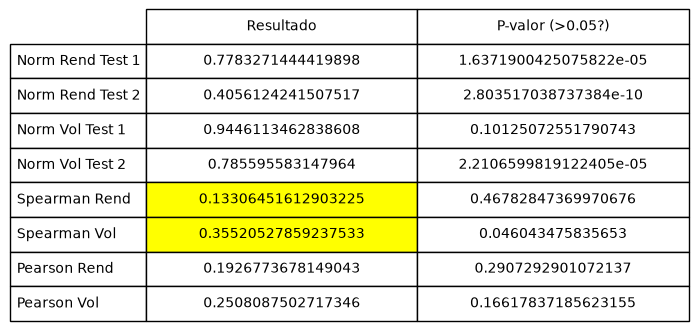

white


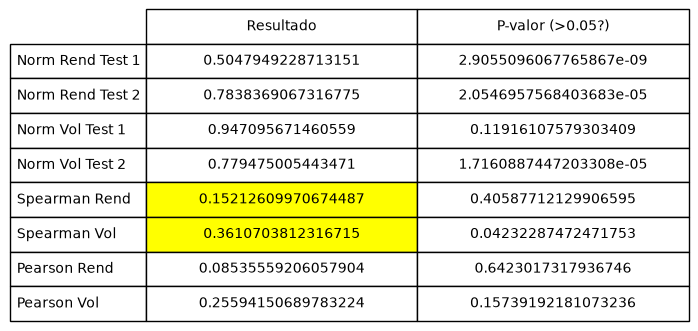

In [226]:
#### Ejecutando pruebas
fecha_test1 = '2025-03-03'
fecha_test2 = '2025-04-03'

pruebas(rentabilidad_diaria_origin, fecha_test1, fecha_test2)
pruebas(rentabilidad_diaria_log, fecha_test1, fecha_test2)